<a href="https://colab.research.google.com/github/Lekanggy/MLrepo/blob/main/Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install gensim

#**Load Authentication Key to kaggle(API-KEY and USERNAME)**

In [2]:
import os
import sys
import json
import builtins
from google.colab import userdata

# --- Prevent Kaggle library 'exit' bug ---
# Inject exit into builtins so it's available globally for any library
if not hasattr(builtins, 'exit'):
    builtins.exit = sys.exit

# --- Kaggle Authentication Setup ---

# Attempt to load credentials from Colab Secrets
try:
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
except Exception:
    # Fallback to kaggle.json if Secrets are not configured
    kaggle_json_path = os.path.expanduser('~/.kaggle/kaggle.json')
    if os.path.exists(kaggle_json_path):
        with open(kaggle_json_path) as f:
            creds = json.load(f)
            os.environ['KAGGLE_USERNAME'] = creds.get('username', '')
            os.environ['KAGGLE_KEY'] = creds.get('key', '')

# Import Kaggle after setting environment variables
from kaggle.api.kaggle_api_extended import KaggleApi

# Validation: Check if keys are actually present and not empty
user = os.environ.get('KAGGLE_USERNAME')
key = os.environ.get('KAGGLE_KEY')

if not user or not key:
    print("❌ ERROR: Kaggle credentials not found!")
    print("Please ensure you have added 'KAGGLE_USERNAME' and 'KAGGLE_KEY' to the 'Secrets' (🔑 icon) in the left sidebar and enabled notebook access.")
else:
    print(f"✅ Credentials detected for user: {user}")
    try:
        api = KaggleApi()
        api.authenticate()
        print("✅ Kaggle Authenticated successfully.")

        # Download the SMS Spam Collection Dataset
        dataset_path = './sms_spam_collection'
        os.makedirs(dataset_path, exist_ok=True)

        api.dataset_download_files(
            'uciml/sms-spam-collection-dataset',
            path=dataset_path,
            unzip=True
        )
        print("✅ Dataset downloaded and unzipped.")
    except Exception as e:
        print(f"❌ Authentication or Download failed: {e}")
        print("Tip: Ensure your Kaggle API key is valid and you have accepted the dataset rules on Kaggle's website.")

✅ Credentials detected for user: idrisaderibigbe
✅ Kaggle Authenticated successfully.
Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
✅ Dataset downloaded and unzipped.


#**Load the Requirements library**

In [3]:
import os
import random
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from IPython.display import display
from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow.keras import layers, Model, Input

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, DataCollatorWithPadding)


#**Set up Configs**

In [4]:
# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Config constants
# Updated to point to the downloaded Kaggle dataset
DATA_PATH = "./sms_spam_collection/spam.csv"
MAX_FEATURES_TFIDF = 5000
MAX_SEQ_LEN = 60
EMBED_DIM = 100
LSTM_UNITS = 64
BATCH_SIZE = 32
EPOCHS = 10
CV_FOLDS = 5
BERT_MODEL_NAME = "distilbert-base-uncased"
BERT_MAX_LEN = 128
BERT_EPOCHS = 3
BERT_BATCH = 16

# Download NLTK data
for pkg in ["punkt", "stopwords", "wordnet", "omw-1.4", "punkt_tab"]:
    try:
        nltk.download(pkg, quiet=True)
    except:
        pass

%matplotlib inline

In [5]:
# Verify what was downloaded
print("\nContents:")
for root, dirs, files_in_dir in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = '  ' * (level + 1)
    for f in files_in_dir:
        fpath = os.path.join(root, f)
        print(f'{subindent}{f}  ({os.path.getsize(fpath)} bytes)')


Contents:
sms_spam_collection/
  spam.csv  (503663 bytes)


#**Exploratory Data analysis**

In [6]:
# Load Data
df = pd.read_csv(DATA_PATH, encoding="latin-1")
df = df.iloc[:, :2]
df.columns = ["label", "text"]
df = df.dropna()
df["label"] = df["label"].map({"ham": 0, "spam": 1}).astype(int)
df["text"] = df["text"].astype(str)

print("Shape:", df.shape)
print("Class distribution:\n", df["label"].value_counts(normalize=True))

Shape: (5572, 2)
Class distribution:
 label
0    0.865937
1    0.134063
Name: proportion, dtype: float64


###Check class Distribution

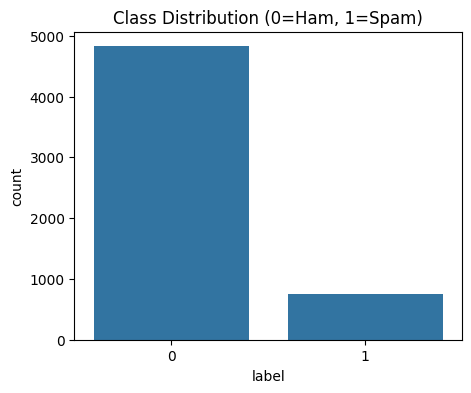

In [7]:
#Class distribution plot
plt.figure(figsize=(5, 4))
sns.countplot(x="label", data=df)
plt.title("Class Distribution (0=Ham, 1=Spam)")
plt.show()

###Message length and Word Cloud distribution

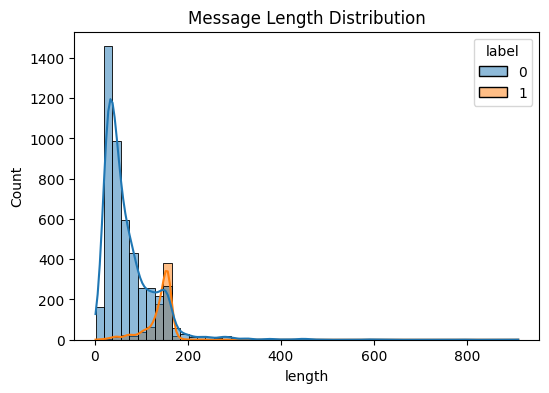

        count        mean        std   min    25%    50%    75%    max
label                                                                 
0      4825.0   71.023627  58.016023   2.0   33.0   52.0   92.0  910.0
1       747.0  138.866131  29.183082  13.0  132.5  149.0  157.0  224.0


In [8]:
#Message length
df["length"] = df["text"].apply(len)
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="length", hue="label", bins=50, kde=True)
plt.title("Message Length Distribution")
plt.show()
print(df.groupby("label")["length"].describe())


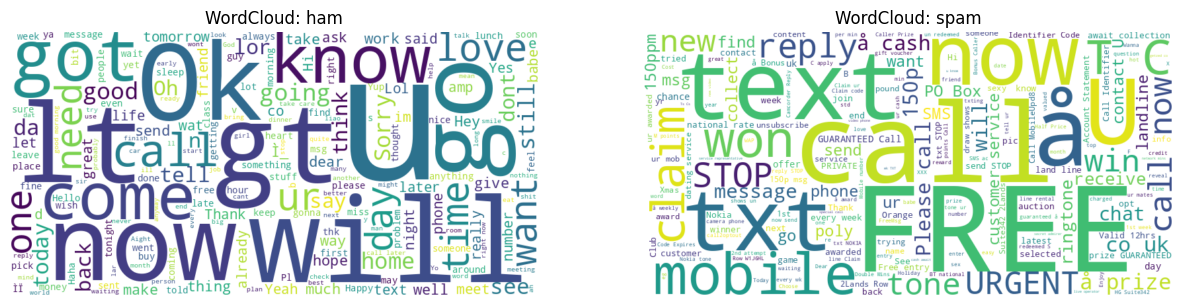

In [9]:
#Word Clouds
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (label, name) in zip(axes, [(0, "ham"), (1, "spam")]):
    text = " ".join(df[df["label"] == label]["text"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"WordCloud: {name}")
plt.show()

###Create helper for text cleaning and lemmatize

In [10]:
STOPWORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()
URL_RE = re.compile(r"http\S+|www\.\S+")
EMAIL_RE = re.compile(r"\S+@\S+")
PHONE_RE = re.compile(r"\b\d{5,}\b")
NONALPHA_RE = re.compile(r"[^a-z\s]")

def clean_text(text: str, use_stopwords: bool = True) -> str:
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = EMAIL_RE.sub(" ", text)
    text = PHONE_RE.sub(" ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = NONALPHA_RE.sub(" ", text)
    tokens = word_tokenize(text)
    if use_stopwords:
        tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return " ".join(tokens)

def lemmatize_text(text: str) -> str:
    tokens = word_tokenize(clean_text(text))
    return " ".join(LEMMATIZER.lemmatize(t, pos="v") for t in tokens)

In [11]:
#Clean Text
texts_raw = df["text"].tolist()
texts_clean = [lemmatize_text(t) for t in texts_raw]
df["clean"] = texts_clean
df["tokens"] = [t.split() for t in texts_clean]
y = df["label"].values

# Split data
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    texts_clean, y, test_size=0.2, stratify=y, random_state=SEED)
X_train_raw, X_test_raw, _, _ = train_test_split(
    texts_raw, y, test_size=0.2, stratify=y, random_state=SEED)

# Class weights
classes = np.unique(y_train)
cw = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, cw))
print("Class weights:", class_weight_dict)


Class weights: {np.int64(0): np.float64(0.577481212749417), np.int64(1): np.float64(3.7265886287625416)}


#**Feature Engineering**

###Build TF_IDF

In [12]:
#Build the TF-IDF
tfidf_vec = TfidfVectorizer(max_features=MAX_FEATURES_TFIDF, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf_vec.fit_transform(X_train_txt)
X_test_tfidf = tfidf_vec.transform(X_test_txt)
print("Shape:", X_train_tfidf.shape)

Shape: (4457, 5000)


###Create the WordEmbedding usinf Word2Vec

In [13]:
print("Training Word2Vec...")
w2v = Word2Vec(sentences=[t.split() for t in X_train_txt], vector_size=EMBED_DIM,
               window=5, min_count=2, workers=4, sg=1, epochs=10, seed=SEED)

def texts_to_sequences(tokenized_texts, w2v_model, max_len=MAX_SEQ_LEN):
    vocab = {w: i + 2 for i, w in enumerate(w2v_model.wv.index_to_key)}
    seqs = []
    for toks in tokenized_texts:
        ids = [vocab.get(t, 1) for t in toks][:max_len]
        ids += [0] * (max_len - len(ids))
        seqs.append(ids)
    return np.array(seqs), vocab

X_train_seq, vocab = texts_to_sequences([t.split() for t in X_train_txt], w2v)
X_test_seq, _ = texts_to_sequences([t.split() for t in X_test_txt], w2v)

emb_matrix = np.zeros((len(vocab) + 2, w2v.vector_size))
for word, idx in vocab.items():
    emb_matrix[idx] = w2v.wv[word]
vocab_size = emb_matrix.shape[0]
print("Features ready.")

Training Word2Vec...
Features ready.


#**Model Implementation**

###Model evaluation helper

In [14]:
def evaluate_model(y_true, y_pred, y_proba=None, name=""):
    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_spam": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_spam": recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    }
    if y_proba is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_proba)
    return metrics

###Traditional ML Approach

Cross-validating NaiveBayes...
[CV] NaiveBayes: macro-F1 = 0.9279 ± 0.0113

=== NaiveBayes ===
              precision    recall  f1-score   support

           0     0.9863    0.9700    0.9781       966
           1     0.8242    0.9128    0.8662       149

    accuracy                         0.9623      1115
   macro avg     0.9053    0.9414    0.9222      1115
weighted avg     0.9647    0.9623    0.9631      1115



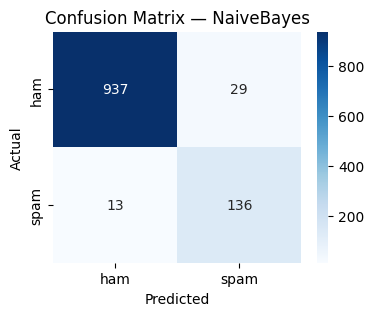

Cross-validating LinearSVC...
[CV] LinearSVC: macro-F1 = 0.9523 ± 0.0081

=== LinearSVC ===
              precision    recall  f1-score   support

           0     0.9896    0.9855    0.9876       966
           1     0.9085    0.9329    0.9205       149

    accuracy                         0.9785      1115
   macro avg     0.9491    0.9592    0.9540      1115
weighted avg     0.9788    0.9785    0.9786      1115



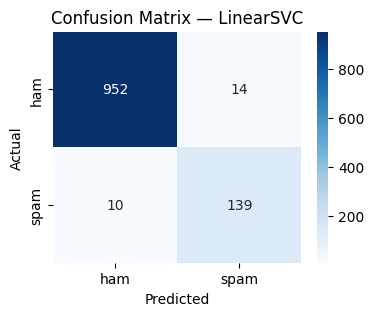

Cross-validating RandomForest...
[CV] RandomForest: macro-F1 = 0.9429 ± 0.0080

=== RandomForest ===
              precision    recall  f1-score   support

           0     0.9797    1.0000    0.9898       966
           1     1.0000    0.8658    0.9281       149

    accuracy                         0.9821      1115
   macro avg     0.9899    0.9329    0.9589      1115
weighted avg     0.9824    0.9821    0.9815      1115



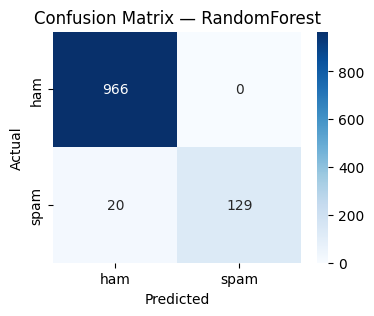

In [15]:
results = []
smote = SMOTE(random_state=SEED)
traditional_models = {
    "NaiveBayes": MultinomialNB(),
    "LinearSVC": LinearSVC(class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=42)
}

#Traning loop
for name, clf in traditional_models.items():
    print(f"Cross-validating {name}...")
    pipe = Pipeline([("clf", clf)])
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    scores = cross_val_score(pipe, X_train_tfidf, y_train, scoring="f1_macro", cv=skf, n_jobs=-1)
    print(f"[CV] {name}: macro-F1 = {scores.mean():.4f} ± {scores.std():.4f}")

    # Fit on full train with SMOTE
    X_use, y_use = smote.fit_resample(X_train_tfidf, y_train)
    clf.fit(X_use, y_use)
    preds = clf.predict(X_test_tfidf)

    proba = None
    if hasattr(clf, "predict_proba"):
        proba = clf.predict_proba(X_test_tfidf)[:, 1]
    elif hasattr(clf, "decision_function"):
        proba = clf.decision_function(X_test_tfidf)

    r = evaluate_model(y_test, preds, proba, name=name)
    r["cv_macro_f1"] = scores.mean()
    results.append(r)


###DeepLearning Approach

In [16]:
def build_bilstm(vocab_size, embedding_matrix, max_len=MAX_SEQ_LEN, embed_dim=EMBED_DIM):
    inp = Input(shape=(max_len,), dtype="int32")
    x = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim,
                         weights=[embedding_matrix], input_length=max_len, trainable=True)(inp)
    x = layers.SpatialDropout1D(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(LSTM_UNITS, return_sequences=False, dropout=0.3))(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"])
    return model

Start Bi-LSTM Traning..


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8958 - auc: 0.9584 - loss: 0.2714 - val_accuracy: 0.9776 - val_auc: 0.9833 - val_loss: 0.0842
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9646 - auc: 0.9850 - loss: 0.1384 - val_accuracy: 0.9798 - val_auc: 0.9853 - val_loss: 0.0722
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9698 - auc: 0.9895 - loss: 0.1115 - val_accuracy: 0.9798 - val_auc: 0.9838 - val_loss: 0.0652
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9816 - auc: 0.9921 - loss: 0.0862 - val_accuracy: 0.9843 - val_auc: 0.9874 - val_loss: 0.0618
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9863 - auc: 0.9962 - loss: 0.0647 - val_accuracy: 0.9821 - val_auc: 0.9835 - val_loss: 0.0615
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9890 - auc: 0.9984 - loss: 0.0434 - val_accuracy: 0.9843 - val_auc: 0.9743 - val_loss: 0.0721
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms

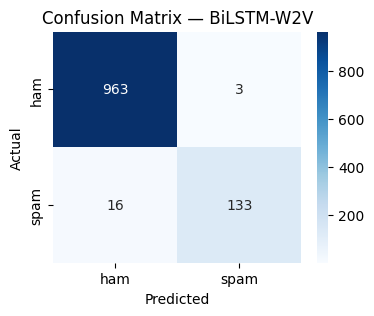

In [17]:
print("Start Bi-LSTM Traning..")
bilstm = build_bilstm(vocab_size, emb_matrix)
es = tf.keras.callbacks.EarlyStopping(monitor="val_auc", patience=2, restore_best_weights=True, mode="max")

history = bilstm.fit(X_train_seq, y_train, validation_split=0.1, epochs=EPOCHS,
                     batch_size=BATCH_SIZE, class_weight=class_weight_dict, callbacks=[es], verbose=1)

proba_lstm = bilstm.predict(X_test_seq).ravel()
preds_lstm = (proba_lstm > 0.5).astype(int)
r = evaluate_model(y_test, preds_lstm, proba_lstm, name="BiLSTM-W2V")
results.append(r)


###Transformer Approach(Using BERT)

In [18]:
#Prepare Dataset for the transformer
class SMSDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=BERT_MAX_LEN):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tok = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tok(self.texts[idx], truncation=True, max_length=self.max_len, padding=False)
        enc["labels"] = int(self.labels[idx])
        return enc

#Helper for computing metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"f1_macro": f1_score(labels, preds, average="macro", zero_division=0)}

In [19]:
#Training Helper
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        w = torch.tensor(list(class_weight_dict.values()), dtype=torch.float, device=logits.device)
        loss_fct = torch.nn.CrossEntropyLoss(weight=w)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [20]:
# Run Training with HF Authentication - Fixed Trainer
from google.colab import userdata

try:
    hf_token = userdata.get('HF_TOKEN')
    print("✅ Hugging Face token found.")
except Exception:
    hf_token = None
    print("ℹ️ HF_TOKEN not found in secrets, continuing with unauthenticated access.")

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME, token=hf_token)
bert_model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=2, token=hf_token)

train_ds = SMSDataset(X_train_raw, y_train, tokenizer)
args = TrainingArguments(
    output_dir="./bert_out",
    num_train_epochs=BERT_EPOCHS,
    per_device_train_batch_size=BERT_BATCH,
    learning_rate=2e-5,
    weight_decay=0.01,
    save_strategy="no",
    logging_steps=50,
    seed=SEED,
    report_to="none"
)

trainer = WeightedTrainer(
    model=bert_model,
    args=args,
    train_dataset=train_ds,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)

trainer.train()

✅ Hugging Face token found.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.333391
100,0.103033
150,0.159023
200,0.098613
250,0.059592
300,0.095460
350,0.053459
400,0.067682
450,0.081815
500,0.044246


TrainOutput(global_step=837, training_loss=0.07356851356573572, metrics={'train_runtime': 82.5124, 'train_samples_per_second': 162.048, 'train_steps_per_second': 10.144, 'total_flos': 215055905935644.0, 'train_loss': 0.07356851356573572, 'epoch': 3.0})


=== DistilBERT ===
              precision    recall  f1-score   support

           0     0.9938    0.9979    0.9959       966
           1     0.9862    0.9597    0.9728       149

    accuracy                         0.9928      1115
   macro avg     0.9900    0.9788    0.9843      1115
weighted avg     0.9928    0.9928    0.9928      1115



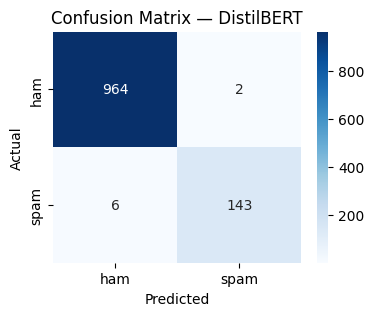

In [21]:
# Run Prediction
device = "cuda" if torch.cuda.is_available() else "cpu"
bert_model.to(device); bert_model.eval()
test_ds = SMSDataset(X_test_raw, y_test, tokenizer)
loader = DataLoader(test_ds, batch_size=32, collate_fn=DataCollatorWithPadding(tokenizer))

probas = []
with torch.no_grad():
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items() if k != "labels"}
        logits = bert_model(**batch).logits
        probas.extend(torch.softmax(logits, dim=-1)[:, 1].cpu().numpy())
probas = np.array(probas)
preds_bert = (probas > 0.5).astype(int)
r = evaluate_model(y_test, preds_bert, probas, name="DistilBERT")
results.append(r)


#**Evaluation and Analysis**

In [22]:
# Error Analysis on Best Model (DistilBERT)
def error_analysis(texts, y_true, y_pred, n=10):
    df_err = pd.DataFrame({"text": texts, "y_true": y_true, "y_pred": y_pred})
    df_err = df_err[df_err.y_true != df_err.y_pred]
    fn = df_err[(df_err.y_true == 1) & (df_err.y_pred == 0)]  # False Negatives
    fp = df_err[(df_err.y_true == 0) & (df_err.y_pred == 1)]  # False Positives
    sample = pd.concat([fn.head(n), fp.head(max(0, n - len(fn)))])
    return sample

print("\n========== ERROR ANALYSIS (DistilBERT) ==========")
ea = error_analysis(X_test_raw, y_test, preds_bert, n=10)
for i, row in ea.iterrows():
    print(f"\n[True={row.y_true} | Pred={row.y_pred}]")
    print(f"  {row.text[:300]}")


========== ERROR ANALYSIS (DistilBERT) ==========

[True=1 | Pred=0]
  Latest News! Police station toilet stolen, cops have nothing to go on!

[True=1 | Pred=0]
  For sale - arsenal dartboard. Good condition but no doubles or trebles!

[True=1 | Pred=0]
  ROMCAPspam Everyone around should be responding well to your presence since you are so warm and outgoing. You are bringing in a real breath of sunshine.

[True=1 | Pred=0]
  Do you realize that in about 40 years, we'll have thousands of old ladies running around with tattoos?

[True=1 | Pred=0]
  RCT' THNQ Adrian for U text. Rgds Vatian

[True=1 | Pred=0]
  Hi ya babe x u 4goten bout me?' scammers getting smart..Though this is a regular vodafone no, if you respond you get further prem rate msg/subscription. Other nos used also. Beware!

[True=0 | Pred=1]
  MY NO. IN LUTON 0125698789 RING ME IF UR AROUND! H*

[True=0 | Pred=1]
  Somebody set up a website where you can play hold em using eve online spacebucks


### **Model Performance Visualization**


In [23]:
# Comparison Table
results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
print("\n========== FINAL MODEL COMPARISON ==========")
display(results_df)



========== FINAL MODEL COMPARISON ==========


,model,accuracy,f1_macro,f1_spam,recall_spam,roc_auc,cv_macro_f1
4,DistilBERT,0.992825,0.984328,0.972789,0.959732,0.994866,NaN
3,BiLSTM-W2V,0.982960,0.961782,0.933333,0.892617,0.986855,NaN
2,RandomForest,0.982063,0.958906,0.928058,0.865772,0.987456,0.942897
1,LinearSVC,0.978475,0.954041,0.920530,0.932886,0.981867,0.952333
0,NaiveBayes,0.962332,0.922161,0.866242,0.912752,0.981811,0.927933


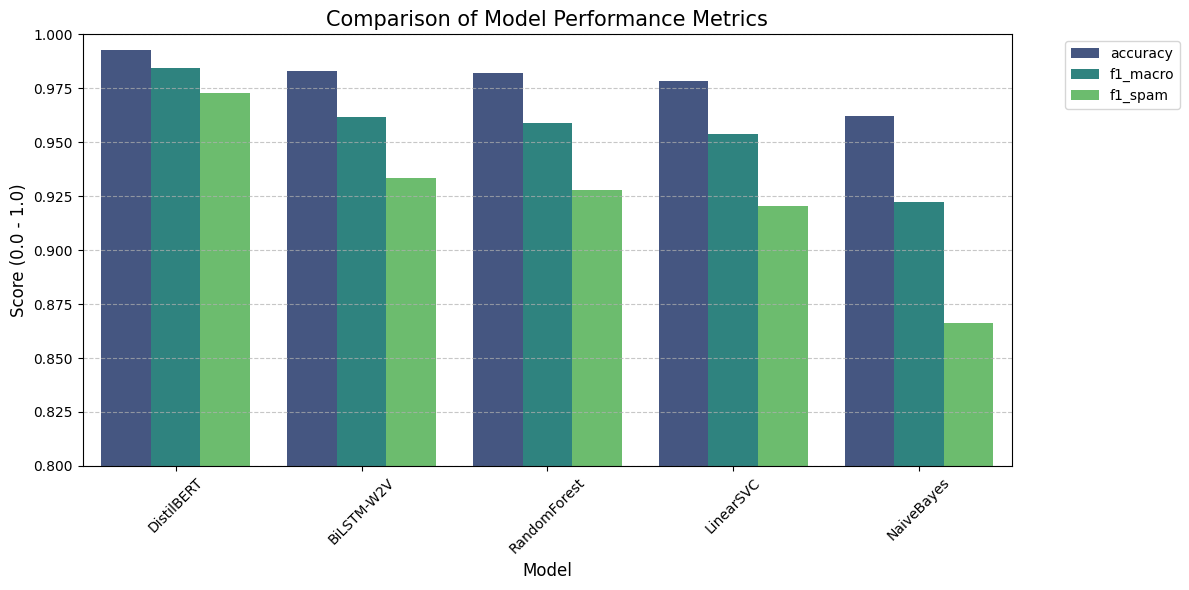

In [24]:
#Prepare data for plotting
# Melt dataframe to make it suitable for a grouped bar chart
plot_df = results_df.melt(id_vars='model', value_vars=['accuracy', 'f1_macro', 'f1_spam'],
                          var_name='Metric', value_name='Score')

#Create the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='model', y='Score', hue='Metric', palette='viridis')

plt.title('Comparison of Model Performance Metrics', fontsize=15)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.ylim(0.8, 1.0)  # Zoom in to see differences clearly since all models are high-performing
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Model Comparison**

| Model | Accuracy | F1 (Macro) | Best For... |
| :--- | :--- | :--- | :--- |
| **DistilBERT** | **99.2%** | **0.984** | **Highest Precision**; understands complex context. |
| **Bi-LSTM** | 98.3% | 0.962 | Capturing word sequences and semantics. |
| **Random Forest**| 98.2% | 0.959 | Robustness and handling class imbalance. |
| **Linear SVC** | 97.8% | 0.954 | **Efficiency**; best performance/speed ratio. |
| **Naive Bayes** | 96.2% | 0.922 | Baseline performance; simple and fast. |

#### **Strengths & Weaknesses**
*   **DistilBERT:**
    *   *Strength:* Best at identifying subtle spam. Lowest error rate.
    *   *Weakness:* Computationally expensive (requires GPU).
*   **Traditional ML (SVC/RF/NB):**
    *   *Strength:* Extremely fast to train and run on CPU. Very effective for common spam keywords.
    *   *Weakness:* Fails on sarcastic or nuance-heavy messages (e.g., "Police station toilet stolen").
*   **Bi-LSTM:**
    *   *Strength:* Better than traditional ML at capturing semantic meaning.
    *   *Weakness:* Harder to tune and requires more data to beat BERT.

#### **Error Analysis Insight**
Most models failed on **short, ambiguous messages** (False Positives) or **jokes/sarcasm** (False Negatives). For a production system, a hybrid approach—using Linear SVC for speed and escalating ambiguous cases to DistilBERT—is recommended.